In [4]:
import pandas as pd
import geopandas as gpd

import sys
sys.path.append('..')  # Adjust the path as per your directory structure

from scripts.constants import *

# Geographies and IMD Processing

In [36]:
# Define paths
# INPUT
lsoa_2011_to_2021_path = TABULAR_IN_DIR / "ONS" / "LSOA_(2011)_to_LSOA_(2021)_to_Local_Authority_District_(2022)_Best_Fit_Lookup_for_EW_(V2).csv"
lsoa_bua_lad_2021_path = TABULAR_IN_DIR / "ONS" / "LSOA_(2021)_to_Built_Up_Area_to_Local_Authority_District_to_Region_(December_2022)_Lookup_in_England_and_Wales_v2.csv"
bua_to_region_2022_path = TABULAR_IN_DIR / "ONS" / "Built_Up_Area_to_Region_(December_2022)_Lookup_in_Great_Britain.csv"
lsoa_prevalence_path = TABULAR_IN_DIR / "NHS" / "output_lsoa_prevalence.csv"

imd_england_path = VECTOR_IN_DIR / "IMD" / "English IMD 2019" / "IMD_2019.shp"
bua_2022_gb_path = VECTOR_IN_DIR / "ONS" / "BUA_2022_GB_6638829375457922612.geojson"
lsoa_2021_path = VECTOR_IN_DIR / "ONS" / "Lower_layer_Super_Output_Areas_(December_2021)_Boundaries_EW_BFC_(V10).geojson"

# OUTPUT
imd_lsoa_bua_path = VECTOR_OUT_DIR / "IMD" / "English_IMD_2019_BUA_filtered.geojson"
imd_lsoa_bua_boundaries_path = VECTOR_OUT_DIR / "IMD" / "English_IMD_2019_BUA_filtered_boundaries.geojson"

# Variables
project_crs = "EPSG:27700"

In [4]:
# Input
lsoa_2011_to_2021_df = pd.read_csv(lsoa_2011_to_2021_path)
lsoa_bua_lad_2021_df = pd.read_csv(lsoa_bua_lad_2021_path)
bua_to_region_2022_df = pd.read_csv(bua_to_region_2022_path)
lsoa_prevalence_df = pd.read_csv(lsoa_prevalence_path)

imd_england_gdf = gpd.read_file(imd_england_path)
lsoa_2021_gdf = gpd.read_file(lsoa_2021_path)
# bua_2022_gb_gdf = gpd.read_file(bua_2022_gb_path)

In [ ]:
# KEEP ONS LSOA boundaries (2021)

# England IMD df with reference to 2021 LSOA names
imd_england_merged_df = imd_england_gdf.merge(lsoa_2011_to_2021_df, left_on='lsoa11cd', right_on='LSOA11CD', how='inner')\
    .drop(columns=['lsoa11cd', 'lsoa11nm', 'lsoa11nmw', 'st_areasha', 'st_lengths', 'ObjectId', 'LSOA01NM', 'LADcd', 'LADnm', 'geometry'])

# Merge lsoa_2021_gdf with imd_england_merged_df
lsoa_2021_merged_gdf = lsoa_2021_gdf.merge(imd_england_merged_df, on='LSOA21CD', how='inner')\
    .drop(columns=['LSOA21NM_x', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'Shape__Area', 'Shape__Length', 'GlobalID', 'FID'])\
        .rename(columns={'LSOA21NM_y': 'LSOA21NM'})
lsoa_2021_merged_gdf

In [13]:
# KEEP IMD LSOA boundaries (2019)

# England IMD df with reference to 2021 LSOA names
imd_england_merged_gdf = imd_england_gdf.merge(lsoa_2011_to_2021_df, left_on='lsoa11cd', right_on='LSOA11CD', how='inner')\
    .drop(columns=['lsoa11cd', 'lsoa11nm', 'lsoa11nmw', 'st_areasha', 'st_lengths', 'ObjectId', 'LSOA01NM', 'LADcd', 'LADnm'])

# Merge lsoa_2021_gdf with imd_england_merged_df
lsoa_2021_merged_gdf = imd_england_merged_gdf.merge(lsoa_2021_gdf.drop(columns=['geometry']), on='LSOA21CD', how='inner')\
    .drop(columns=['LSOA21NM_x', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'Shape__Area', 'Shape__Length', 'GlobalID', 'FID'])\
        .rename(columns={'LSOA21NM_y': 'LSOA21NM'})
lsoa_2021_merged_gdf

,IMD_Rank,IMD_Decile,IMDScore,IMDRank0,IMDDec0,IncScore,IncRank,IncDec,EmpScore,EmpRank,...,WorkPop,geometry,LSOA11CD,LSOA11NM,LSOA21CD,LAD22CD,LAD22NM,LAD22NMW,LSOA21NM,LSOA21NMW
0,29199,9,6.208,29199,9,0.007,32831,10,0.010,32742,...,715.00,"POLYGON ((532105.092 182011.230, 532162.491 18...",E01000001,City of London 001A,E01000001,E09000001,City of London,NaN,City of London 001A,
1,30379,10,5.143,30379,10,0.034,29901,10,0.027,31190,...,619.75,"POLYGON ((532746.813 181786.891, 532671.688 18...",E01000002,City of London 001B,E01000002,E09000001,City of London,NaN,City of London 001B,
2,14915,5,19.402,14915,5,0.086,18510,6,0.086,15103,...,804.00,"POLYGON ((532135.145 182198.119, 532158.250 18...",E01000003,City of London 001C,E01000003,E09000001,City of London,NaN,City of London 001C,
3,8678,3,28.652,8678,3,0.211,6029,2,0.136,7833,...,683.00,"POLYGON ((533807.946 180767.770, 533649.063 18...",E01000005,City of London 001E,E01000005,E09000001,City of London,NaN,City of London 001E,
4,14486,5,19.837,14486,5,0.117,14023,5,0.059,21692,...,1284.50,"POLYGON ((545122.049 184314.931, 545271.917 18...",E01000006,Barking and Dagenham 016A,E01000006,E09000002,Barking and Dagenham,NaN,Barking and Dagenham 016A,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32839,116,1,74.468,116,1,0.470,90,1,0.341,176,...,1625.00,"POLYGON ((334934.507 393421.201, 334921.819 39...",E01033764,Liverpool 022E,E01034399,E08000012,Liverpool,NaN,Liverpool 022G,
32840,945,1,59.599,945,1,0.362,838,1,0.280,700,...,907.75,"POLYGON ((335087.000 388951.000, 335125.000 38...",E01033765,Liverpool 061D,E01033765,E08000012,Liverpool,NaN,Liverpool 061D,
32841,12842,4,21.895,12842,4,0.099,16430,6,0.073,18004,...,735.25,"POLYGON ((338804.207 388364.881, 338831.644 38...",E01033766,Liverpool 042G,E01034404,E08000012,Liverpool,NaN,Liverpool 042H,
32842,422,1,66.704,422,1,0.396,442,1,0.291,550,...,650.25,"POLYGON ((335584.014 387799.682, 335678.000 38...",E01033767,Liverpool 050J,E01033767,E08000012,Liverpool,NaN,Liverpool 050J,


In [14]:
bua_2021_merged_gdf = lsoa_2021_merged_gdf.merge(lsoa_bua_lad_2021_df, on='LSOA21CD', how='inner')\
    .drop(columns=['LAD22CD_x', 'LAD22NM_x', 'LAD22NMW_x', 'LSOA21NM_x', 'LSOA21NMW_x', 'ObjectId'])\
        .rename(columns={'LSOA21NM_y': 'LSOA21NM', 'LSOA21NMW_y': 'LSOA21NMW', 'LAD22CD_y': 'LAD22CD', 'LAD22NM_y': 'LAD22NM', 'LAD22NMW_y': 'LAD22NMW'})
bua_2021_merged_gdf

,IMD_Rank,IMD_Decile,IMDScore,IMDRank0,IMDDec0,IncScore,IncRank,IncDec,EmpScore,EmpRank,...,LSOA21NMW,BUA22CD,BUA22NM,BUA22NMW,LAD22CD,LAD22NM,LAD22NMW,RGN22CD,RGN22NM,RGN22NMW
0,29199,9,6.208,29199,9,0.007,32831,10,0.010,32742,...,NaN,E63004906,City and County of the City of London,NaN,E09000001,City of London,NaN,E12000007,London,NaN
1,30379,10,5.143,30379,10,0.034,29901,10,0.027,31190,...,NaN,E63004906,City and County of the City of London,NaN,E09000001,City of London,NaN,E12000007,London,NaN
2,14915,5,19.402,14915,5,0.086,18510,6,0.086,15103,...,NaN,E63004906,City and County of the City of London,NaN,E09000001,City of London,NaN,E12000007,London,NaN
3,8678,3,28.652,8678,3,0.211,6029,2,0.136,7833,...,NaN,E63004906,City and County of the City of London,NaN,E09000001,City of London,NaN,E12000007,London,NaN
4,14486,5,19.837,14486,5,0.117,14023,5,0.059,21692,...,NaN,E63004859,Barking and Dagenham,NaN,E09000002,Barking and Dagenham,NaN,E12000007,London,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32839,116,1,74.468,116,1,0.470,90,1,0.341,176,...,NaN,E63001374,Liverpool,NaN,E08000012,Liverpool,NaN,E12000002,North West,NaN
32840,945,1,59.599,945,1,0.362,838,1,0.280,700,...,NaN,E63001374,Liverpool,NaN,E08000012,Liverpool,NaN,E12000002,North West,NaN
32841,12842,4,21.895,12842,4,0.099,16430,6,0.073,18004,...,NaN,E63001374,Liverpool,NaN,E08000012,Liverpool,NaN,E12000002,North West,NaN
32842,422,1,66.704,422,1,0.396,442,1,0.291,550,...,NaN,E63001374,Liverpool,NaN,E08000012,Liverpool,NaN,E12000002,North West,NaN


In [15]:
# Merge bua_2021_merged_gdf with bua_to_region_2022_df
# There are more rows because there are Built Up Areas that can belong to different regions (e.g. East of England and London)
# bua_to_region_2022_df[bua_to_region_2022_df.duplicated(subset='BUA22CD', keep=False)].sort_values('BUA22CD')
region_merged_gdf = bua_2021_merged_gdf.merge(bua_to_region_2022_df, on='BUA22CD', how='left')\
    .drop(columns=['BUA22NM_x', 'BUA22NMW_x', 'RGN22CD_x', 'RGN22NM_x', 'WHOLE_PART', 'ObjectId'])\
    .rename(columns={'BUA22NM_y': 'BUA22NM', 'BUA22NMW_y': 'BUA22NMW', 'RGN22CD_y': 'RGN22CD', 'RGN22NM_y': 'RGN22NM'})
region_merged_gdf

,IMD_Rank,IMD_Decile,IMDScore,IMDRank0,IMDDec0,IncScore,IncRank,IncDec,EmpScore,EmpRank,...,BUA22CD,LAD22CD,LAD22NM,LAD22NMW,RGN22NMW,BUA22NM,BUA22NMW,BUA22NMG,RGN22CD,RGN22NM
0,29199,9,6.208,29199,9,0.007,32831,10,0.010,32742,...,E63004906,E09000001,City of London,NaN,NaN,City and County of the City of London,NaN,NaN,E12000007,London
1,30379,10,5.143,30379,10,0.034,29901,10,0.027,31190,...,E63004906,E09000001,City of London,NaN,NaN,City and County of the City of London,NaN,NaN,E12000007,London
2,14915,5,19.402,14915,5,0.086,18510,6,0.086,15103,...,E63004906,E09000001,City of London,NaN,NaN,City and County of the City of London,NaN,NaN,E12000007,London
3,8678,3,28.652,8678,3,0.211,6029,2,0.136,7833,...,E63004906,E09000001,City of London,NaN,NaN,City and County of the City of London,NaN,NaN,E12000007,London
4,14486,5,19.837,14486,5,0.117,14023,5,0.059,21692,...,E63004859,E09000002,Barking and Dagenham,NaN,NaN,Barking and Dagenham,NaN,NaN,E12000007,London
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36534,116,1,74.468,116,1,0.470,90,1,0.341,176,...,E63001374,E08000012,Liverpool,NaN,NaN,Liverpool,NaN,NaN,E12000002,North West
36535,945,1,59.599,945,1,0.362,838,1,0.280,700,...,E63001374,E08000012,Liverpool,NaN,NaN,Liverpool,NaN,NaN,E12000002,North West
36536,12842,4,21.895,12842,4,0.099,16430,6,0.073,18004,...,E63001374,E08000012,Liverpool,NaN,NaN,Liverpool,NaN,NaN,E12000002,North West
36537,422,1,66.704,422,1,0.396,442,1,0.291,550,...,E63001374,E08000012,Liverpool,NaN,NaN,Liverpool,NaN,NaN,E12000002,North West


In [22]:
desired_order = ['LSOA11CD', 'LSOA11NM', 'LSOA21CD', 'LSOA21NM', 'LSOA21NMW',
                 'LAD22CD', 'LAD22NM', 'LAD22NMW', 'BUA22CD', 'BUA22NMW', 'BUA22NMG', 
                 'RGN22NMW', 'BUA22NM', 'RGN22CD', 'RGN22NM', 
                 'IMD_Rank', 'IMD_Decile', 'IMDScore', 'IMDRank0', 'IMDDec0', 'IncScore',
                 'IncRank', 'IncDec', 'EmpScore', 'EmpRank', 'EmpDec', 'EduScore',
                 'EduRank', 'EduDec', 'HDDScore', 'HDDRank', 'HDDDec', 'CriScore',
                 'CriRank', 'CriDec', 'BHSScore', 'BHSRank', 'BHSDec', 'EnvScore',
                 'EnvRank', 'EnvDec', 'IDCScore', 'IDCRank', 'IDCDec', 'IDOScore',
                 'IDORank', 'IDODec', 'CYPScore', 'CYPRank', 'CYPDec', 'ASScore',
                 'ASRank', 'ASDec', 'GBScore', 'GBRank', 'GBDec', 'WBScore', 'WBRank',
                 'WBDec', 'IndScore', 'IndRank', 'IndDec', 'OutScore', 'OutRank',
                 'OutDec', 'TotPop', 'DepChi', 'Pop16_59', 'Pop60+', 'WorkPop', 'geometry']

# Reorder the columns
region_merged_gdf = region_merged_gdf.reindex(columns=desired_order).to_crs(project_crs)
region_merged_gdf.to_file(imd_lsoa_bua_path)
region_merged_gdf.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

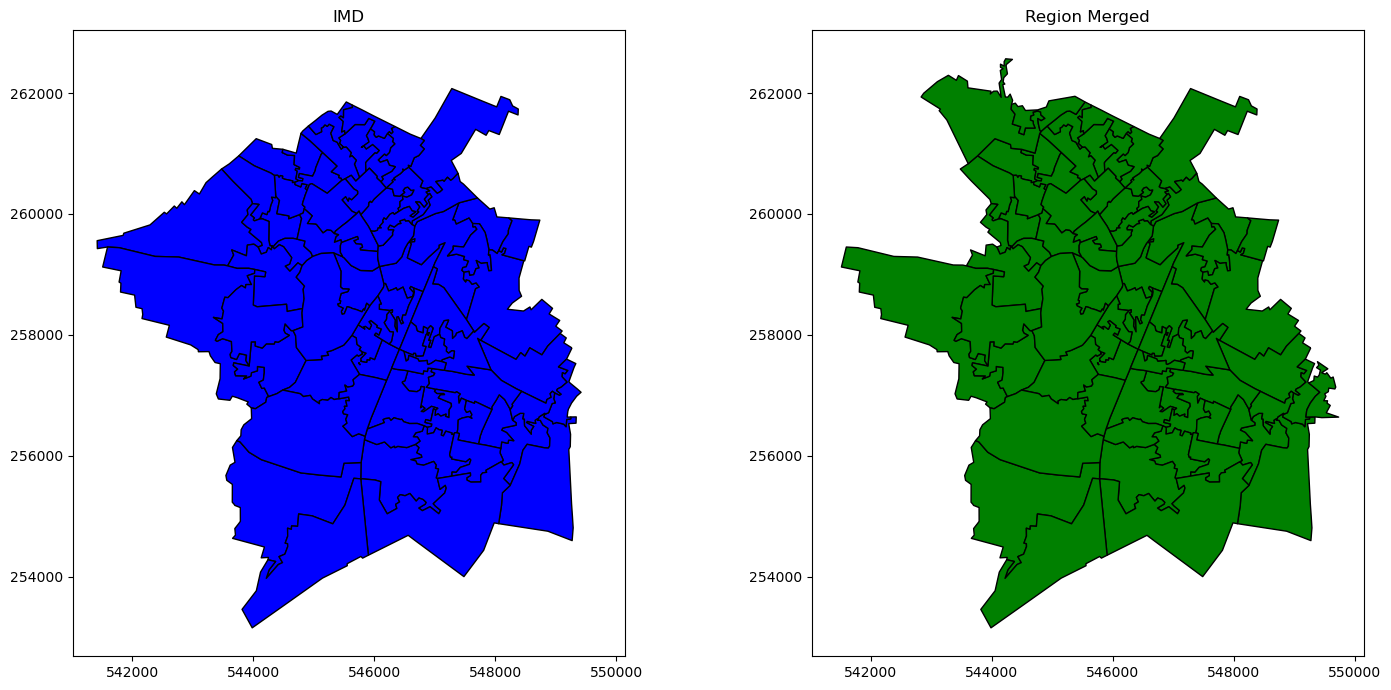

In [102]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Plot the first GeoDataFrame
imd_england_gdf[imd_england_gdf['LADnm'] == 'Cambridge'].plot(ax=axes[0], color='blue', edgecolor='black')
axes[0].set_title('IMD')

# Plot the second GeoDataFrame
region_merged_gdf[region_merged_gdf['BUA22NM'] == 'Cambridge (Cambridge)'].plot(ax=axes[1], color='green', edgecolor='black')
axes[1].set_title('Region Merged')

xlim = [min(axes[0].get_xlim()[0], axes[1].get_xlim()[0]), max(axes[0].get_xlim()[1], axes[1].get_xlim()[1])]
ylim = [min(axes[0].get_ylim()[0], axes[1].get_ylim()[0]), max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])]

for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
geo_filter = 'BUA22NM'
place_name = 'Cambridge (Cambridge)'

region_merged_gdf[region_merged_gdf[geo_filter] == place_name]

,IMD_Rank,IMD_Decile,LSOA01NM,LADcd,LADnm,IMDScore,IMDRank0,IMDDec0,IncScore,IncRank,...,BUA22CD,LAD22CD,LAD22NM,LAD22NMW,RGN22NMW,BUA22NM,BUA22NMW,BUA22NMG,RGN22CD,RGN22NM
20267,16929,6,Cambridge 006A,E07000008,Cambridge,17.072,16929,6,0.078,19864,...,E63003443,E07000008,Cambridge,NaN,NaN,Cambridge (Cambridge),NaN,NaN,E12000006,East of England
20268,8504,3,Cambridge 006B,E07000008,Cambridge,28.975,8504,3,0.145,10964,...,E63003443,E07000008,Cambridge,NaN,NaN,Cambridge (Cambridge),NaN,NaN,E12000006,East of England
20269,12570,4,Cambridge 006C,E07000008,Cambridge,22.252,12570,4,0.086,18564,...,E63003443,E07000008,Cambridge,NaN,NaN,Cambridge (Cambridge),NaN,NaN,E12000006,East of England
20270,5217,2,Cambridge 006D,E07000008,Cambridge,36.991,5217,2,0.193,7106,...,E63003443,E07000008,Cambridge,NaN,NaN,Cambridge (Cambridge),NaN,NaN,E12000006,East of England
20271,13227,5,Cambridge 006E,E07000008,Cambridge,21.423,13227,5,0.110,14906,...,E63003443,E07000008,Cambridge,NaN,NaN,Cambridge (Cambridge),NaN,NaN,E12000006,East of England
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35565,20186,7,Cambridge 012F,E07000008,Cambridge,13.772,20186,7,0.072,21071,...,E63003443,E07000008,Cambridge,NaN,NaN,Cambridge (Cambridge),NaN,NaN,E12000006,East of England
35566,19395,6,Cambridge 007G,E07000008,Cambridge,14.552,19395,6,0.020,32190,...,E63003443,E07000008,Cambridge,NaN,NaN,Cambridge (Cambridge),NaN,NaN,E12000006,East of England
35570,14009,5,Cambridge 003G,E07000008,Cambridge,20.410,14009,5,0.077,20021,...,E63003443,E07000008,Cambridge,NaN,NaN,Cambridge (Cambridge),NaN,NaN,E12000006,East of England
35888,15854,5,South Cambridgeshire 006G,E07000012,South Cambridgeshire,18.319,15854,5,0.118,13872,...,E63003443,E07000012,South Cambridgeshire,NaN,NaN,Cambridge (Cambridge),NaN,NaN,E12000006,East of England


# Health Data Processing

In [2]:
nhs_prevalence_lsoa_path = TABULAR_IN_DIR / "NHS" / "output_lsoa_prevalence.csv"
imd_lsoa_bua_path = VECTOR_OUT_DIR / "IMD" / "English_IMD_2019_BUA_filtered.geojson"

nhs_prevalence_lsoa_df = pd.read_csv(nhs_prevalence_lsoa_path)
imd_lsoa_bua_gdf = gpd.read_file(imd_lsoa_bua_path)
nhs_prevalence_lsoa_df

,lsoa_code,group_code,register,list,prevalence
0,E01000001,AF,22.989515,1594.092476,0.014422
1,E01000001,AST,62.014553,1594.092476,0.038903
2,E01000001,CAN,35.455365,1594.092476,0.022242
3,E01000001,CHD,28.203917,1594.092476,0.017693
4,E01000001,CKD,40.450900,1430.189714,0.028284
...,...,...,...,...,...
691861,W01001930,OST,1.128342,50.890254,0.022172
691862,W01001930,PAD,0.844405,100.061359,0.008439
691863,W01001930,PC,0.493739,100.061359,0.004934
691864,W01001930,RA,0.866650,84.187555,0.010294


In [23]:
nhs_prevalence_pivot_df = nhs_prevalence_lsoa_df.pivot_table(
         index='lsoa_code', 
         columns='group_code', 
         values=['register', 'list', 'prevalence'], 
         aggfunc='first'
     )
# Flatten the MultiIndex columns
nhs_prevalence_pivot_df.columns = ['_'.join(col).strip() for col in nhs_prevalence_pivot_df.columns.values]
nhs_prevalence_pivot_df.reset_index(inplace=True)
nhs_prevalence_pivot_df

,lsoa_code,list_AF,list_AST,list_CAN,list_CHD,list_CKD,list_COPD,list_CVDPP,list_DEM,list_DEP,...,register_HF,register_HYP,register_LD,register_MH,register_OB,register_OST,register_PAD,register_PC,register_RA,register_STIA
0,E01000001,1594.092476,1594.092476,1594.092476,1594.092476,1430.189714,1594.092476,1160.624061,1562.528525,1430.189714,...,9.803482,143.180226,0.797893,12.978324,59.125098,6.354819,5.131018,4.605008,7.408481,16.444784
1,E01000002,1434.558716,1434.558716,1434.558716,1434.558716,1289.355373,1434.558716,957.898458,1408.768894,1289.355373,...,8.561373,125.005641,0.775794,11.540745,52.734409,5.216904,4.511222,4.040715,6.462737,14.347201
2,E01000003,1710.237264,1710.237264,1710.237264,1710.237264,1533.591140,1710.237264,1233.751158,1685.977917,1533.591140,...,11.554941,169.439744,1.122375,15.641415,72.098198,6.854591,6.156431,5.498338,8.785790,19.420250
3,E01000005,1432.981138,1432.981138,1432.981138,1432.981138,1165.261275,1432.981138,487.472759,1417.113544,1165.261275,...,5.844772,101.454342,4.833806,16.603985,62.715848,1.415980,3.354183,1.967693,4.633413,10.558007
4,E01000006,2171.961397,2171.961397,2171.961397,2171.961397,1666.674117,2171.961397,1251.933578,2166.604266,1666.674117,...,7.541185,218.771920,8.995995,16.714698,175.222934,1.297301,3.822864,3.020572,10.987255,15.933534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32941,W01001568,148.076080,148.076080,148.076080,148.076080,122.883884,148.076080,92.057408,147.901168,122.883884,...,1.971970,26.134843,0.524195,0.998466,12.095999,0.862076,0.923581,0.324501,1.637513,3.245014
32942,W01001599,8.003397,8.003397,8.003397,8.003397,6.817506,8.003397,4.461078,8.058140,6.817506,...,0.095915,1.658293,0.099382,0.067025,1.018032,0.113096,0.057780,0.043913,0.079582,0.228810
32943,W01001906,21.016005,21.016005,21.016005,21.016005,17.674699,21.016005,12.928875,20.979267,17.674699,...,0.194684,4.136738,0.239528,0.177950,2.007137,0.291608,0.173817,0.068008,0.182782,0.545045
32944,W01001907,434.261416,434.261416,434.261416,434.261416,351.225792,434.261416,252.212394,434.223188,351.225792,...,3.811185,74.859976,3.498544,3.434959,41.106149,4.535391,3.552515,2.192699,3.622810,10.773387


In [8]:
nhs_prevalence_lsoa_df.columns

Index(['lsoa_code', 'group_code', 'register', 'list', 'prevalence'], dtype='object')

In [10]:
imd_lsoa_bua_gdf[imd_lsoa_bua_gdf['LAD22NM'] == 'Cambridge']

,LSOA11CD,LSOA11NM,LSOA21CD,LSOA21NM,LSOA21NMW,LAD22CD,LAD22NM,LAD22NMW,BUA22CD,BUA22NMW,...,IndDec,OutScore,OutRank,OutDec,TotPop,DepChi,Pop16_59,Pop60+,WorkPop,geometry
20267,E01017943,Cambridge 006A,E01017943,Cambridge 006A,None,E07000008,Cambridge,None,E63003443,None,...,1,0.718,6339,2,1819,323,1269,227,1276.00,"POLYGON ((546548.384 259275.223, 546780.000 25..."
20268,E01017944,Cambridge 006B,E01017944,Cambridge 006B,None,E07000008,Cambridge,None,E63003443,None,...,4,0.360,9986,4,1308,278,813,217,836.50,"POLYGON ((547861.809 260127.298, 547912.312 26..."
20269,E01017945,Cambridge 006C,E01017945,Cambridge 006C,None,E07000008,Cambridge,None,E63003443,None,...,3,0.142,12989,4,1739,279,1249,211,1223.25,"POLYGON ((547333.000 259899.000, 547357.000 25..."
20270,E01017946,Cambridge 006D,E01017946,Cambridge 006D,None,E07000008,Cambridge,None,E63003443,None,...,4,0.590,7512,3,1499,358,898,243,894.50,"POLYGON ((547743.000 259838.000, 547834.876 25..."
20271,E01017947,Cambridge 006E,E01017947,Cambridge 006E,None,E07000008,Cambridge,None,E63003443,None,...,3,0.172,12538,4,1623,345,965,313,965.25,"POLYGON ((548180.000 259429.000, 548158.000 25..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35563,E01032792,Cambridge 003F,E01032792,Cambridge 003F,None,E07000008,Cambridge,None,E63003443,None,...,8,0.297,10788,4,1280,231,879,170,882.25,"POLYGON ((546505.226 259913.572, 546519.505 25..."
35564,E01032794,Cambridge 012E,E01032794,Cambridge 014D,None,E07000008,Cambridge,None,E63003443,None,...,4,0.409,9382,3,1185,161,612,412,618.50,"POLYGON ((544780.063 257028.809, 544829.939 25..."
35565,E01032795,Cambridge 012F,E01035523,Cambridge 014C,None,E07000008,Cambridge,None,E63003443,None,...,1,0.014,15071,5,2542,366,1995,181,2013.75,"POLYGON ((546204.813 257249.359, 546129.746 25..."
35566,E01032797,Cambridge 007G,E01035515,Cambridge 007H,None,E07000008,Cambridge,None,E63003443,None,...,1,1.228,2780,1,5211,236,4658,317,4680.25,"POLYGON ((545455.018 258388.223, 545471.070 25..."


In [37]:
imd_lsoa_bua_gdf[['LSOA11CD', 'LSOA11NM', 'LSOA21CD', 'LSOA21NM', 'LSOA21NMW', 'LAD22CD',
       'LAD22NM', 'LAD22NMW', 'BUA22CD', 'BUA22NMW', 'BUA22NMG', 'RGN22NMW',
       'BUA22NM', 'RGN22CD', 'RGN22NM', 'geometry']].to_file(imd_lsoa_bua_boundaries_path)
imd_lsoa_bua_boundaries_path = VECTOR_OUT_DIR / "IMD" / "English_IMD_2019_BUA_filtered_boundaries.geojson"

In [47]:
import requests
def download_file(url: str, filename: str, folder_path: Path) -> str:
    # Ensure the folder exists
    folder_path.mkdir(parents=True, exist_ok=True)
    
    # Get the filename from the URL
    file_path = folder_path / filename
    
    # Download the file
    response = requests.get(url)
    response.raise_for_status()  # Check if the request was successful
    
    # Save the file
    with open(file_path, 'wb') as file:
        file.write(response.content)

    return filename, response.status_code

In [51]:
x = imd_lsoa_bua_gdf[imd_lsoa_bua_gdf['RGN22NM'] == 'London']
x.LAD22NM.unique()

array(['City of London', 'Barking and Dagenham', 'Barnet', 'Bexley',
       'Brent', 'Bromley', 'Camden', 'Croydon', 'Ealing', 'Enfield',
       'Greenwich', 'Hackney', 'Hammersmith and Fulham', 'Haringey',
       'Harrow', 'Havering', 'Hillingdon', 'Hounslow', 'Islington',
       'Kensington and Chelsea', 'Kingston upon Thames', 'Lambeth',
       'Lewisham', 'Merton', 'Newham', 'Redbridge',
       'Richmond upon Thames', 'Southwark', 'Sutton', 'Tower Hamlets',
       'Waltham Forest', 'Wandsworth', 'Westminster', 'Thurrock',
       'Slough', 'Buckinghamshire', 'Epping Forest', 'Broxbourne',
       'Hertsmere', 'Three Rivers', 'Watford', 'Dartford', 'Sevenoaks',
       'Elmbridge', 'Epsom and Ewell', 'Reigate and Banstead',
       'Spelthorne', 'Tandridge'], dtype=object)

In [25]:
z = pd.merge(x, nhs_prevalence_pivot_df, left_on='LSOA11CD', right_on='lsoa_code', how='left')
z

,LSOA11CD,LSOA11NM,LSOA21CD,LSOA21NM,LSOA21NMW,LAD22CD,LAD22NM,LAD22NMW,BUA22CD,BUA22NMW,...,register_HF,register_HYP,register_LD,register_MH,register_OB,register_OST,register_PAD,register_PC,register_RA,register_STIA
0,E01000001,City of London 001A,E01000001,City of London 001A,None,E09000001,City of London,None,E63004906,None,...,9.803482,143.180226,0.797893,12.978324,59.125098,6.354819,5.131018,4.605008,7.408481,16.444784
1,E01000002,City of London 001B,E01000002,City of London 001B,None,E09000001,City of London,None,E63004906,None,...,8.561373,125.005641,0.775794,11.540745,52.734409,5.216904,4.511222,4.040715,6.462737,14.347201
2,E01000003,City of London 001C,E01000003,City of London 001C,None,E09000001,City of London,None,E63004906,None,...,11.554941,169.439744,1.122375,15.641415,72.098198,6.854591,6.156431,5.498338,8.785790,19.420250
3,E01000005,City of London 001E,E01000005,City of London 001E,None,E09000001,City of London,None,E63004906,None,...,5.844772,101.454342,4.833806,16.603985,62.715848,1.415980,3.354183,1.967693,4.633413,10.558007
4,E01000006,Barking and Dagenham 016A,E01000006,Barking and Dagenham 016A,None,E09000002,Barking and Dagenham,None,E63004859,None,...,7.541185,218.771920,8.995995,16.714698,175.222934,1.297301,3.822864,3.020572,10.987255,15.933534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5133,E01033742,Greenwich 007F,E01033742,Greenwich 007F,None,E09000011,Greenwich,None,E63004986,None,...,6.038519,151.835411,6.973809,14.294667,124.209273,1.511341,4.691178,3.058828,4.422466,13.546832
5134,E01033743,Greenwich 002H,E01033743,Greenwich 002H,None,E09000011,Greenwich,None,E63004986,None,...,9.783971,237.535018,13.121996,19.426321,165.003340,2.517874,5.871129,3.919953,5.546341,20.602865
5135,E01033744,Greenwich 007G,E01033744,Greenwich 007G,None,E09000011,Greenwich,None,E63004986,None,...,11.411483,261.273872,13.836144,23.383706,185.608680,2.628794,7.515180,4.635027,6.846368,23.711332
5136,E01033745,Greenwich 002I,E01033745,Greenwich 002I,None,E09000011,Greenwich,None,E63004986,None,...,11.980059,273.426945,15.475556,22.122373,176.775466,3.509571,7.074971,4.512666,6.414273,24.721259


In [4]:
nhs_prevalence_lsoa_df.sort_values(by=['prevalence'], ascending=False)

,lsoa_code,group_code,register,list,prevalence
426186,E01020866,HYP,283.253810,991.016528,0.285821
426861,E01020898,OB,327.106077,1156.454648,0.282852
426420,E01020877,OB,365.863356,1303.756628,0.280622
593409,E01028997,HYP,681.395592,2435.659187,0.279758
426441,E01020878,OB,384.081139,1375.142315,0.279303
...,...,...,...,...,...
675472,E01033011,DEM,0.206181,2093.891430,0.000098
680554,E01033276,DEM,0.411925,4786.114137,0.000086
680239,E01033261,DEM,0.308666,6042.828503,0.000051
675451,E01033010,DEM,0.186603,4783.335962,0.000039
